<div style="
    font-size: 42px;
    font-weight: bold;
    font-family: Segoe UI;
    color: #1f2937;
    border-bottom: 3px solid #3b82f6;
    padding-bottom: 10px;
    margin: 30px 0 20px 0;
">
    Projet 6 - Classifiez automatiquement des biens de consommation
</div>

# Introduction

Dans le cadre de ce projet, notre objectif est d’étudier la faisabilité d’un modèle capable de classer automatiquement des produits e-commerce en fonction de leur description textuelle.

Pour cela, nous avons utilisé un jeu de données issu du site Flipkart, une plateforme de commerce en ligne. Ce jeu de données contient des informations sur les produits, comme leur nom, leur description et leur catégorie.

Notre mission est de tester plusieurs techniques de traitement du texte et de voir si nous arrivons à retrouver automatiquement les catégories des produits à partir de leur description.

Nous avons structuré notre travail en plusieurs étapes : préparation des données, modélisation, évaluation des résultats et synthèse comparative des approches testées.

# Sommaire

1. Chargement et préparation des données
2. Nettoyage et traitement des textes
3. Analyses exploratoires
4. Représentation des textes (BoW, TF-IDF, Word2Vec, USE, BERT)
5. Évaluation des modèles par ARI et t-SNE
6. Analyses complémentaires (silhouette score, mots par cluster)
7. Synthèse des résultats

<div style="
    font-size: 32px;
    font-weight: bold;
    font-family: Segoe UI;
    color: #1f2937;
    border-bottom: 3px solid #3b82f6;
    padding-bottom: 10px;
    margin: 30px 0 20px 0;
    text-align: center
">
    Chargement et préparation des données
</div>

<div style="
    font-size: 24px;
    font-weight: bold;
    font-family: Segoe UI;
    color: #374151;
    border-left: 5px solid #3b82f6;
    padding-left: 12px;
    margin: 25px 0 15px 0;
">
    Importation
</div>

In [1]:
# ─── IMPORTS ───────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import ast

# ─── LECTURE DU FICHIER CSV ─────────────────────────────────────────────────
# Remplace ce chemin par le tien si besoin
csv_path = r'C:\Users\chouh\OneDrive\Desktop\Openclassrooms\Formation Data Scientist\projet 6\Flipkart\flipkart_com-ecommerce_sample_1050.csv'

df = pd.read_csv(csv_path)

# ─── APERÇU DES DONNÉES ─────────────────────────────────────────────────────
df.head()

,uniq_id,crawl_timestamp,product_url,product_name,product_category_tree,pid,retail_price,discounted_price,image,is_FK_Advantage_product,description,product_rating,overall_rating,brand,product_specifications
0,55b85ea15a1536d46b7190ad6fff8ce7,2016-04-30 03:22:56 +0000,http://www.flipkart.com/elegance-polyester-mul...,Elegance Polyester Multicolor Abstract Eyelet ...,"[""Home Furnishing >> Curtains & Accessories >>...",CRNEG7BKMFFYHQ8Z,1899.0,899.0,55b85ea15a1536d46b7190ad6fff8ce7.jpg,False,Key Features of Elegance Polyester Multicolor ...,No rating available,No rating available,Elegance,"{""product_specification""=>[{""key""=>""Brand"", ""v..."
1,7b72c92c2f6c40268628ec5f14c6d590,2016-04-30 03:22:56 +0000,http://www.flipkart.com/sathiyas-cotton-bath-t...,Sathiyas Cotton Bath Towel,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",BTWEGFZHGBXPHZUH,600.0,449.0,7b72c92c2f6c40268628ec5f14c6d590.jpg,False,Specifications of Sathiyas Cotton Bath Towel (...,No rating available,No rating available,Sathiyas,"{""product_specification""=>[{""key""=>""Machine Wa..."
2,64d5d4a258243731dc7bbb1eef49ad74,2016-04-30 03:22:56 +0000,http://www.flipkart.com/eurospa-cotton-terry-f...,Eurospa Cotton Terry Face Towel Set,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",BTWEG6SHXTDB2A2Y,NaN,NaN,64d5d4a258243731dc7bbb1eef49ad74.jpg,False,Key Features of Eurospa Cotton Terry Face Towe...,No rating available,No rating available,Eurospa,"{""product_specification""=>[{""key""=>""Material"",..."
3,d4684dcdc759dd9cdf41504698d737d8,2016-06-20 08:49:52 +0000,http://www.flipkart.com/santosh-royal-fashion-...,SANTOSH ROYAL FASHION Cotton Printed King size...,"[""Home Furnishing >> Bed Linen >> Bedsheets >>...",BDSEJT9UQWHDUBH4,2699.0,1299.0,d4684dcdc759dd9cdf41504698d737d8.jpg,False,Key Features of SANTOSH ROYAL FASHION Cotton P...,No rating available,No rating available,SANTOSH ROYAL FASHION,"{""product_specification""=>[{""key""=>""Brand"", ""v..."
4,6325b6870c54cd47be6ebfbffa620ec7,2016-06-20 08:49:52 +0000,http://www.flipkart.com/jaipur-print-cotton-fl...,Jaipur Print Cotton Floral King sized Double B...,"[""Home Furnishing >> Bed Linen >> Bedsheets >>...",BDSEJTHNGWVGWWQU,2599.0,698.0,6325b6870c54cd47be6ebfbffa620ec7.jpg,False,Key Features of Jaipur Print Cotton Floral Kin...,No rating available,No rating available,Jaipur Print,"{""product_specification""=>[{""key""=>""Machine Wa..."


In [2]:
# ─── INFORMATIONS GÉNÉRALES SUR LES DONNÉES ─────────────────────────────────
print("Dimensions du DataFrame :", df.shape)
df.info()

# ─── STATISTIQUES DES COLONNES NUMÉRIQUES ───────────────────────────────────
df.describe()

# ─── RECHERCHE DE VALEURS MANQUANTES ────────────────────────────────────────
print("\nValeurs manquantes par colonne :")
print(df.isna().sum())

# ─── RECHERCHE DE DOUBLONS ──────────────────────────────────────────────────
print("\nNombre de doublons :", df.duplicated().sum())

Dimensions du DataFrame : (1050, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   uniq_id                  1050 non-null   object 
 1   crawl_timestamp          1050 non-null   object 
 2   product_url              1050 non-null   object 
 3   product_name             1050 non-null   object 
 4   product_category_tree    1050 non-null   object 
 5   pid                      1050 non-null   object 
 6   retail_price             1049 non-null   float64
 7   discounted_price         1049 non-null   float64
 8   image                    1050 non-null   object 
 9   is_FK_Advantage_product  1050 non-null   bool   
 10  description              1050 non-null   object 
 11  product_rating           1050 non-null   object 
 12  overall_rating           1050 non-null   object 
 13  brand                    712 non-null    

In [3]:
# ─── EXTRACTION DE LA CATÉGORIE PRINCIPALE ───────────────────────────────────
def extract_main_category(tree_str):
    try:
        # Évaluation de la chaîne de type "[\"Category >> SubCategory\"]"
        parts = ast.literal_eval(tree_str)
        # Séparation pour garder seulement la catégorie principale avant '>>'
        return parts[0].split('>>')[0].strip()
    except Exception:
        return None

# Application de la fonction sur la colonne product_category_tree
df['main_category'] = df['product_category_tree'].astype(str).apply(extract_main_category)

# Vérification des catégories extraites
print("Exemples de catégories extraites :")
print(df['main_category'].unique())

Exemples de catégories extraites :
['Home Furnishing' 'Baby Care' 'Watches' 'Home Decor & Festive Needs'
 'Kitchen & Dining' 'Beauty and Personal Care' 'Computers']


Répartition des catégories :
main_category
Home Furnishing               150
Baby Care                     150
Watches                       150
Home Decor & Festive Needs    150
Kitchen & Dining              150
Beauty and Personal Care      150
Computers                     150
Name: count, dtype: int64


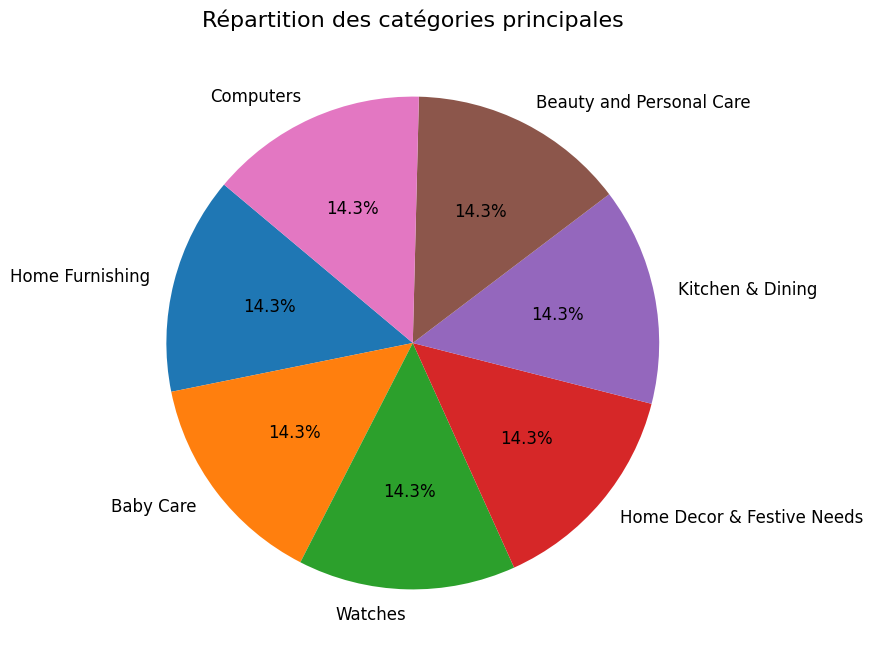

In [4]:
# ─── COMPTAGE DES OCCURRENCES PAR CATÉGORIE ──────────────────────────────────
category_counts = df['main_category'].value_counts()

print("Répartition des catégories :")
print(category_counts)

# ─── VISUALISATION AVEC UN GRAPH CIRCULAIRE ─────────────────────────────────
plt.figure(figsize=(8, 8))
category_counts.plot.pie(autopct='%1.1f%%', startangle=140, textprops={'fontsize': 12})
plt.title("Répartition des catégories principales", fontsize=16)
plt.ylabel("")  # Retire le label inutile
plt.show()

<div style="
    font-size: 24px;
    font-weight: bold;
    font-family: Segoe UI;
    color: #374151;
    border-left: 5px solid #3b82f6;
    padding-left: 12px;
    margin: 25px 0 15px 0;
">
    Analyses exploratoire
</div>

Statistiques sur les prix :
count      1049.000000
mean       2186.197331
std        7639.229411
min          35.000000
25%         555.000000
50%         999.000000
75%        1999.000000
max      201000.000000
Name: retail_price, dtype: float64


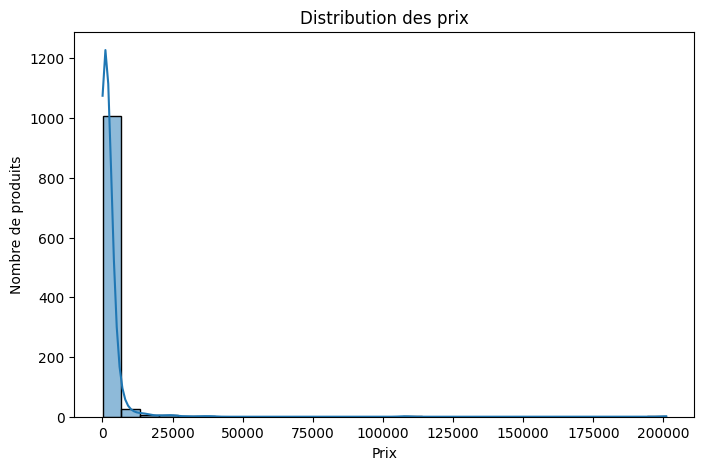

In [5]:
# ─── CONVERSION DE LA COLONNE RETAIL_PRICE EN NUMÉRIQUE ─────────────────────
df['retail_price'] = pd.to_numeric(df['retail_price'], errors='coerce')

# ─── STATISTIQUES SUR LES PRIX ──────────────────────────────────────────────
print("Statistiques sur les prix :")
print(df['retail_price'].describe())

# ─── VISUALISATION DE LA DISTRIBUTION DES PRIX ──────────────────────────────
plt.figure(figsize=(8, 5))
sns.histplot(df['retail_price'].dropna(), bins=30, kde=True)
plt.title("Distribution des prix")
plt.xlabel("Prix")
plt.ylabel("Nombre de produits")
plt.show()

Statistiques sur les ratings :
count    161.000000
mean       3.880745
std        1.122582
min        1.000000
25%        3.500000
50%        4.000000
75%        5.000000
max        5.000000
Name: product_rating, dtype: float64


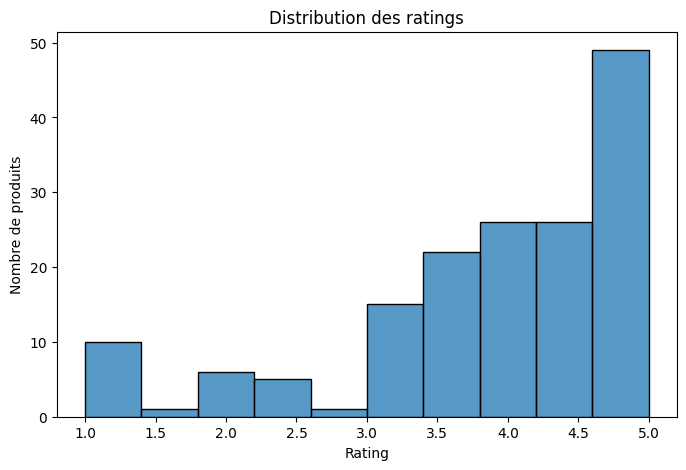

In [6]:
# ─── CONVERSION DE LA COLONNE PRODUCT_RATING EN NUMÉRIQUE ───────────────────
df['product_rating'] = pd.to_numeric(df['product_rating'], errors='coerce')

# ─── STATISTIQUES SUR LES RATINGS ───────────────────────────────────────────
print("Statistiques sur les ratings :")
print(df['product_rating'].describe())

# ─── VISUALISATION DE LA DISTRIBUTION DES RATINGS ───────────────────────────
plt.figure(figsize=(8, 5))
sns.histplot(df['product_rating'].dropna(), bins=10, kde=False)
plt.title("Distribution des ratings")
plt.xlabel("Rating")
plt.ylabel("Nombre de produits")
plt.show()

Répartition des types d'avis :
is_FK_Advantage_product
False    993
True      57
Name: count, dtype: int64


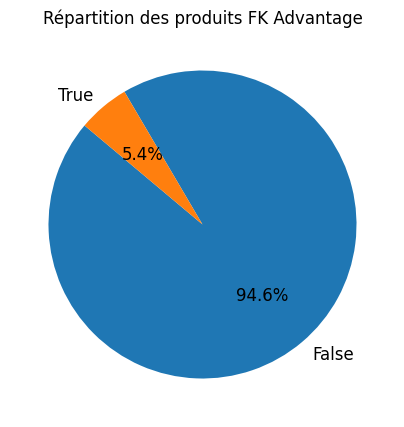

In [7]:
# ─── COMPTAGE DES TYPES D'AVIS ───────────────────────────────────────────────
print("Répartition des types d'avis :")
print(df['is_FK_Advantage_product'].value_counts())

# ─── VISUALISATION DES TYPES D'AVIS ─────────────────────────────────────────
plt.figure(figsize=(5, 5))
df['is_FK_Advantage_product'].value_counts().plot.pie(autopct='%1.1f%%', startangle=140, textprops={'fontsize': 12})
plt.title("Répartition des produits FK Advantage")
plt.ylabel("")
plt.show()

<div style="
    font-size: 32px;
    font-weight: bold;
    font-family: Segoe UI;
    color: #1f2937;
    border-bottom: 3px solid #3b82f6;
    padding-bottom: 10px;
    margin: 30px 0 20px 0;
    text-align: center
">
    Nettoyage et prétraitement des textes
</div>

Un texte brut contient souvent beaucoup d'éléments inutiles pour un modèle de machine learning :  
des caractères spéciaux, des chiffres, des mots trop fréquents comme "the", "and", "in", etc.

Nous avons donc appliqué plusieurs traitements pour nettoyer et simplifier les descriptions des produits :
- **Suppression des caractères spéciaux et des chiffres**,  
- **Mise en minuscules**,  
- **Suppression des mots vides** (appelés "stopwords" en anglais),
- **Lemmatisation** : cela permet de ramener les mots à leur forme de base (par exemple, "running" devient "run").

Ces étapes permettent de conserver **l’essentiel du contenu**, en supprimant tout ce qui pourrait **perturber l’analyse**.  
Cela améliore considérablement la qualité des représentations que nous allons construire par la suite.

Nous avons aussi combiné le **nom du produit** avec sa **description** pour enrichir le texte analysé.

<div style="
    font-size: 24px;
    font-weight: bold;
    font-family: Segoe UI;
    color: #374151;
    border-left: 5px solid #3b82f6;
    padding-left: 12px;
    margin: 25px 0 15px 0;
">
    Préparation du texte
</div>

In [9]:
# ─── CONCATÉNATION PRODUCT_NAME ET DESCRIPTION ──────────────────────────────
df['product_name'] = df['product_name'].astype(str)
df['description'] = df['description'].astype(str)
df['text'] = df['product_name'] + " " + df['description']

# ─── VÉRIFICATION ───────────────────────────────────────────────────────────
print("Exemple de texte combiné :")
df['text'].sample(5).values

Exemple de texte combiné :


array(['Adidas Ice Drive and Dynamic Pulse Combo Set Flipkart.com: Buy Adidas Ice Drive and Dynamic Pulse Combo Set online only for Rs. 315 from Flipkart.com. Only Genuine Products. 30 Day Replacement Guarantee. Free Shipping. Cash On Delivery!',
       "NammaBaby Baby Girl's Animal Print Top & Pyjama Set Specifications of NammaBaby Baby Girl's Animal Print Top & Pyjama Set General Details Pattern Animal Print Ideal For Baby Girl's Night Suit Details Number of Contents in Sales Package Pack of 2 Fabric Cotton Type Top & Pyjama Set In the Box 1 Top, 1 Bottom",
       'Bharatcraft Showpiece  -  5 cm Key Features of Bharatcraft Showpiece  -  5 cm Polyresin Height - 5 cm Width - 10 cm,Bharatcraft Showpiece  -  5 cm (Polyresin, Brown) Price: Rs. 499 This is an Imperial Golden King Money Frog that is large and heavy. Made of high quality earth material, it suits perfectly the use in Period 8 because earth energy rules the period. This product will be an envy for your peers. The Money Frog is

<div style="
    font-size: 24px;
    font-weight: bold;
    font-family: Segoe UI;
    color: #374151;
    border-left: 5px solid #3b82f6;
    padding-left: 12px;
    margin: 25px 0 15px 0;
">
    Nettoyage (ponctuation, caractères spéciaux, chiffres)
</div>

In [10]:
# ─── IMPORTS ET CONFIGURATIONS NLP ──────────────────────────────────────────
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk
import re
import string

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# ─── FONCTION DE NETTOYAGE ──────────────────────────────────────────────────
def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'http\S+', ' ', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', ' ', text)
    text = ' '.join([word for word in text.split() if len(word) > 2])
    return text.strip()

# ─── APPLICATION DU NETTOYAGE ───────────────────────────────────────────────
df['clean_text'] = df['text'].apply(clean_text)

# ─── VÉRIFICATION ───────────────────────────────────────────────────────────
print("Exemple de texte nettoyé :")
df[['text', 'clean_text']].sample(5)

Exemple de texte nettoyé :


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\chouh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\chouh\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,text,clean_text
10,Calibro SW-125 Analog-Digital Watch - For Men...,calibro analogdigital watch for men boys calib...
943,"Al Fakher Pegs'N'Pipes Mint, Double Apple Hook...",fakher pegsnpipes mint double apple hookah fla...
467,"Shaun Solid Baby Boy's Grey, Dark Blue Track P...",shaun solid baby boys grey dark blue track pan...
702,Jaipur Raga Lord Krishna Showpiece - 14 cm B...,jaipur raga lord krishna showpiece buy jaipur ...
165,Rockmantra Cute Two Cats Ceramic Mug Rockmantr...,rockmantra cute two cats ceramic mug rockmantr...


<div style="
    font-size: 24px;
    font-weight: bold;
    font-family: Segoe UI;
    color: #374151;
    border-left: 5px solid #3b82f6;
    padding-left: 12px;
    margin: 25px 0 15px 0;
">
    Tokenisation
</div>

In [11]:
# ─── TOKENISATION ───────────────────────────────────────────────────────────
def tokenize_text(text):
    return text.split()

df['tokens'] = df['clean_text'].apply(tokenize_text)

# ─── VÉRIFICATION ───────────────────────────────────────────────────────────
print("Exemple de tokens :")
df[['clean_text', 'tokens']].sample(5)

Exemple de tokens :


,clean_text,tokens
572,times tms partywedding analog watch for women ...,"[times, tms, partywedding, analog, watch, for,..."
91,aapno rajasthan princess design showpiece buy ...,"[aapno, rajasthan, princess, design, showpiece..."
330,asus rtn mbps wireless router buy asus rtn mbp...,"[asus, rtn, mbps, wireless, router, buy, asus,..."
1031,kerastase nutritive bain satin complete nutrit...,"[kerastase, nutritive, bain, satin, complete, ..."
259,nirlon kadhai buy nirlon kadhai for online nir...,"[nirlon, kadhai, buy, nirlon, kadhai, for, onl..."


<div style="
    font-size: 24px;
    font-weight: bold;
    font-family: Segoe UI;
    color: #374151;
    border-left: 5px solid #3b82f6;
    padding-left: 12px;
    margin: 25px 0 15px 0;
">
    Stop words
</div>

In [12]:
# ─── SUPPRESSION DES STOPWORDS ──────────────────────────────────────────────
def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

df['tokens_no_stop'] = df['tokens'].apply(remove_stopwords)

# ─── VÉRIFICATION ───────────────────────────────────────────────────────────
print("Exemple après suppression des stopwords :")
df[['tokens', 'tokens_no_stop']].sample(5)

Exemple après suppression des stopwords :


,tokens,tokens_no_stop
854,"[kliqvik, six, port, usb, hub, for, android, m...","[kliqvik, six, port, usb, hub, android, mobile..."
346,"[yardley, red, roses, and, lace, combo, set, f...","[yardley, red, roses, lace, combo, set, flipka..."
140,"[rockmantra, fogg, tree, ceramic, mug, rockman...","[rockmantra, fogg, tree, ceramic, mug, rockman..."
102,"[lord, ganesha, regular, showpiece, key, featu...","[lord, ganesha, regular, showpiece, key, featu..."
367,"[tplink, archer, dual, band, router, buy, tpli...","[tplink, archer, dual, band, router, buy, tpli..."


<div style="
    font-size: 24px;
    font-weight: bold;
    font-family: Segoe UI;
    color: #374151;
    border-left: 5px solid #3b82f6;
    padding-left: 12px;
    margin: 25px 0 15px 0;
">
    Lemmatisation
</div>

In [13]:
# ─── LEMMATISATION ──────────────────────────────────────────────────────────
def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

df['lemmatized_tokens'] = df['tokens_no_stop'].apply(lemmatize_tokens)

# ─── VÉRIFICATION ───────────────────────────────────────────────────────────
print("Exemple après lemmatisation :")
df[['tokens_no_stop', 'lemmatized_tokens']].sample(5)

Exemple après lemmatisation :


,tokens_no_stop,lemmatized_tokens
367,"[tplink, archer, dual, band, router, buy, tpli...","[tplink, archer, dual, band, router, buy, tpli..."
202,"[earth, conscious, graphic, print, baby, boys,...","[earth, conscious, graphic, print, baby, boy, ..."
594,"[miracle, retail, bonsai, wild, plant, artific...","[miracle, retail, bonsai, wild, plant, artific..."
628,"[wonderchef, windsor, roaster, pot, key, featu...","[wonderchef, windsor, roaster, pot, key, featu..."
455,"[milton, school, water, bottle, flipkartcom, b...","[milton, school, water, bottle, flipkartcom, b..."


<div style="
    font-size: 24px;
    font-weight: bold;
    font-family: Segoe UI;
    color: #374151;
    border-left: 5px solid #3b82f6;
    padding-left: 12px;
    margin: 25px 0 15px 0;
">
    Texte final
</div>

In [14]:
# ─── RECONSTRUCTION DU TEXTE FINAL ──────────────────────────────────────────
df['final_clean_text'] = df['lemmatized_tokens'].apply(lambda tokens: ' '.join(tokens))

# ─── VÉRIFICATION ───────────────────────────────────────────────────────────
print("Texte final prêt pour la vectorisation :")
df[['final_clean_text']].sample(5)

Texte final prêt pour la vectorisation :


,final_clean_text
219,mcb export mini drawer chest showpiece mcb exp...
878,woven terry cotton bath towel woven terry cott...
481,lapguard pavilion series cell laptop battery b...
407,trendnet wireless home router buy trendnet wir...
311,wild stone red juice combo set flipkartcom buy...


<div style="
    font-size: 24px;
    font-weight: bold;
    font-family: Segoe UI;
    color: #374151;
    border-left: 5px solid #3b82f6;
    padding-left: 12px;
    margin: 25px 0 15px 0;
">
    Analyses exploratoire
</div>

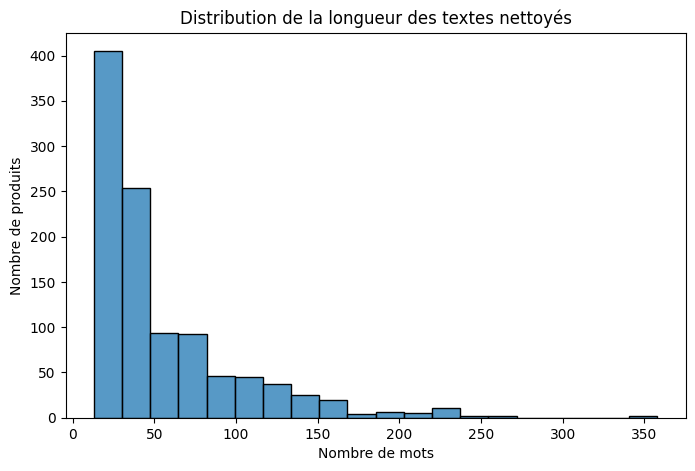

Nombre de textes vides après nettoyage : 0


In [15]:
# ─── ANALYSE DES LONGUEURS ──────────────────────────────────────────────────
df['text_length'] = df['final_clean_text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(8, 5))
sns.histplot(df['text_length'], bins=20, kde=False)
plt.title("Distribution de la longueur des textes nettoyés")
plt.xlabel("Nombre de mots")
plt.ylabel("Nombre de produits")
plt.show()

# Vérification du nombre de textes vides
nb_empty = (df['final_clean_text'].str.strip() == '').sum()
print(f"Nombre de textes vides après nettoyage : {nb_empty}")

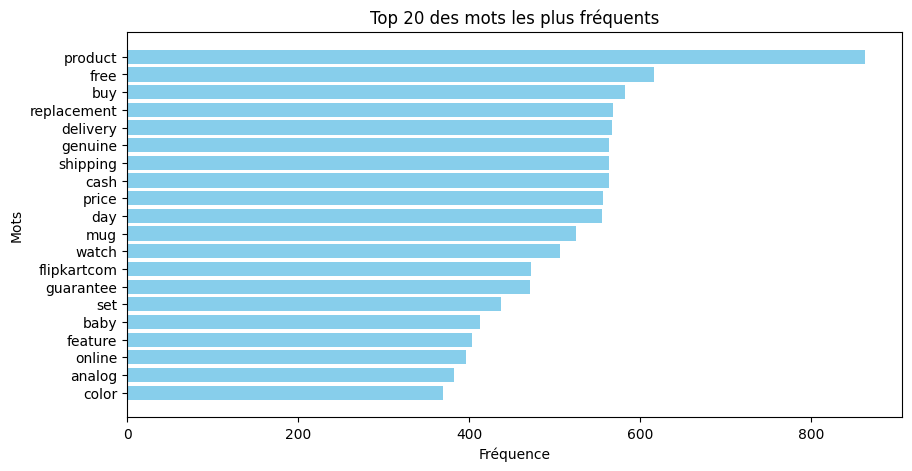

In [58]:
import matplotlib.pyplot as plt

# ─── EXTRACTION DES MOTS ET FRÉQUENCES ──────────────────────────────────────
top_words = word_freq.most_common(20)
words, counts = zip(*top_words)

# ─── AFFICHAGE GRAPHIQUE ────────────────────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.barh(words[::-1], counts[::-1], color='skyblue')  # Affiche du haut vers le bas
plt.title("Top 20 des mots les plus fréquents")
plt.xlabel("Fréquence")
plt.ylabel("Mots")
plt.show()

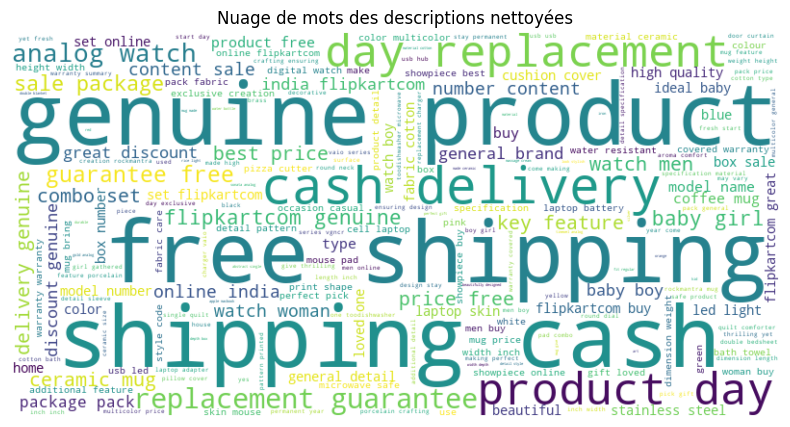

In [17]:
# ─── NUAGE DE MOTS ──────────────────────────────────────────────────────────
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Fusion en une seule chaîne de texte
all_text = ' '.join(df['final_clean_text'])

# Génération du nuage de mots
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Nuage de mots des descriptions nettoyées")
plt.show()

<div style="
    font-size: 36px;
    font-weight: bold;
    font-family: Segoe UI;
    color: #1f2937;
    border-bottom: 3px solid #3b82f6;
    padding-bottom: 10px;
    margin: 30px 0 20px 0;
    text-align: center
">
    Etape 1 - Etudier la faisabilité de classification en utilisant des méthodes NLP basiques
</div>

Dans cette première étape, nous avons testé des méthodes dites **"classiques"** pour transformer nos textes en données exploitables par un modèle.

### Bag of Words (Sac de mots)

La première technique utilisée est le **Bag of Words**.  
Cette méthode consiste à compter la présence de chaque mot dans le texte.  
Par exemple, si le mot "watch" apparaît 3 fois, la valeur sera 3.  
Le modèle ne tient pas compte du contexte, uniquement de la fréquence.

Cette méthode est **simple mais efficace** pour détecter les mots caractéristiques des catégories.

### TF-IDF (Term Frequency - Inverse Document Frequency)

Nous avons ensuite testé la méthode **TF-IDF**, qui va plus loin que le simple comptage.  
TF-IDF donne **plus de poids aux mots rares et caractéristiques** d’une catégorie,  
et **réduit l’importance des mots trop fréquents**, qui n’apportent pas d’information utile (comme "product" ou "free").

L’objectif est de voir si ces représentations **permettent déjà de regrouper les produits par catégorie**,  
sans utiliser de techniques plus complexes.

Nous avons également encodé les catégories des produits sous forme numérique pour faciliter les comparaisons.


<div style="
    font-size: 24px;
    font-weight: bold;
    font-family: Segoe UI;
    color: #374151;
    border-left: 5px solid #3b82f6;
    padding-left: 12px;
    margin: 25px 0 15px 0;
">
    Bag of Words
</div>

In [19]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer_bow = CountVectorizer()
X_bow = vectorizer_bow.fit_transform(df['final_clean_text'])

print("Shape de la matrice BoW :", X_bow.shape)

Shape de la matrice BoW : (1050, 4970)


In [20]:
from sklearn.preprocessing import LabelEncoder

# ─── ENCODAGE DES CATÉGORIES RÉELLES ────────────────────────────────────────
le = LabelEncoder()
y_cat_num = le.fit_transform(df['main_category'])
i_cat = le.classes_  # Noms des catégories

print("Catégories :", list(i_cat))

Catégories : ['Baby Care', 'Beauty and Personal Care', 'Computers', 'Home Decor & Festive Needs', 'Home Furnishing', 'Kitchen & Dining', 'Watches']


In [21]:
from sklearn import manifold, cluster, metrics
import time
import numpy as np

def ARI_fct(features):
    t0 = time.time()
    num_labels = len(i_cat)

    # Convertir en dense si besoin
    data = features.toarray() if hasattr(features, "toarray") else features

    # t-SNE
    tsne = manifold.TSNE(n_components=2, perplexity=30, n_iter=2000,
                         init='random', learning_rate=200, random_state=42)
    X_tsne = tsne.fit_transform(data)

    # KMeans
    kmeans = cluster.KMeans(n_clusters=num_labels, n_init=100, random_state=42)
    y_pred = kmeans.fit_predict(X_tsne)

    # ARI
    ari = np.round(metrics.adjusted_rand_score(y_cat_num, y_pred), 4)
    duration = np.round(time.time() - t0, 2)
    print(f"ARI : {ari}   Temps : {duration}s")

    return ari, X_tsne, y_pred

In [22]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def TSNE_visu_fct(X_tsne, y_true, y_pred, ari):
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    cmap = plt.get_cmap('tab10')

    # Vraies catégories
    scatter1 = axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_true, cmap=cmap, s=10)
    axes[0].set_title("t-SNE – Catégories réelles")
    handles1 = [mpatches.Patch(color=cmap(i), label=label) for i, label in enumerate(i_cat)]
    axes[0].legend(handles=handles1, loc="best")

    # Clusters KMeans
    scatter2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_pred, cmap=cmap, s=10)
    axes[1].set_title("t-SNE – Clusters KMeans")
    cluster_ids = sorted(set(y_pred))
    handles2 = [mpatches.Patch(color=cmap(i), label=f"Cluster {i}") for i in cluster_ids]
    axes[1].legend(handles=handles2, loc="best")

    plt.suptitle(f"Visualisation t-SNE – ARI = {ari}", fontsize=14)
    plt.tight_layout()
    plt.show()

In [23]:
import numpy as np

def top_words_per_cluster(X_vectorized, labels, vectorizer, top_n=5):
    df_vect = pd.DataFrame(X_vectorized.toarray(), columns=vectorizer.get_feature_names_out())
    df_vect['cluster'] = labels

    for c in np.unique(labels):
        print(f"\nCluster {c} :")
        top_words = df_vect[df_vect['cluster'] == c].drop('cluster', axis=1).sum().sort_values(ascending=False).head(top_n)
        print(top_words)

C:\Users\chouh\anaconda3\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
C:\Users\chouh\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Le fichier spécifié est introuvable
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\chouh\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\chouh\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\chouh\anaconda3\Lib\subprocess.py", line 1026, in __init__
    sel

ARI : 0.4608   Temps : 16.41s


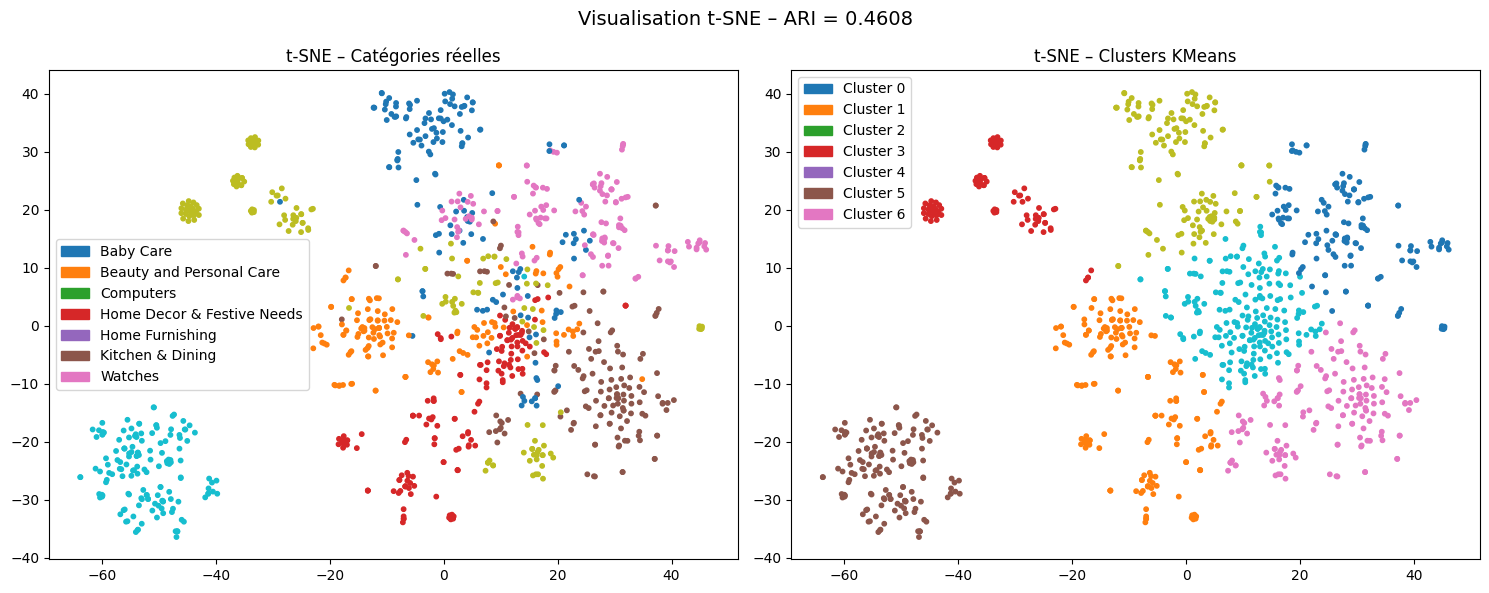

In [24]:
# ─── CALCUL ARI ET AFFICHAGE t-SNE ──────────────────────────────────────────
ari_bow, X_tsne_bow, cluster_labels_bow = ARI_fct(X_bow)
TSNE_visu_fct(X_tsne_bow, y_cat_num, cluster_labels_bow, ari_bow)

In [92]:
def top_words_table(X_vectorized, labels, vectorizer, top_n=5):
    import pandas as pd
    df_vect = pd.DataFrame(X_vectorized.toarray(), columns=vectorizer.get_feature_names_out())
    df_vect['cluster'] = labels
    
    table_data = {}
    for c in sorted(df_vect['cluster'].unique()):
        top_words = df_vect[df_vect['cluster'] == c].drop('cluster', axis=1).sum().sort_values(ascending=False).head(top_n)
        table_data[f"Cluster {c}"] = [f"{word} ({count})" for word, count in zip(top_words.index, top_words.values)]
    
    df_table = pd.DataFrame(table_data)
    display(df_table)

# Appel pour BoW
top_words_table(X_bow, cluster_labels_bow, vectorizer_bow)

,Cluster 0,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5,Cluster 6
0,single (128),laptop (274),mug (525),watch (500),showpiece (305),baby (391),product (128)
1,cover (95),set (230),ceramic (276),analog (371),price (161),cotton (270),free (119)
2,design (86),combo (214),perfect (135),men (234),product (150),girl (231),box (114)
3,product (86),replacement (208),coffee (118),woman (163),best (115),detail (178),type (107)
4,inch (85),product (203),gift (108),day (136),free (113),fabric (160),flipkartcom (107)


<div style="
    font-size: 24px;
    font-weight: bold;
    font-family: Segoe UI;
    color: #374151;
    border-left: 5px solid #3b82f6;
    padding-left: 12px;
    margin: 25px 0 15px 0;
">
    Bag of Words (version ACP)
</div>

In [27]:
from sklearn.decomposition import PCA

X_bow_dense = X_bow.toarray()

pca_bow = PCA(n_components=0.99, random_state=42)
X_bow_pca = pca_bow.fit_transform(X_bow_dense)

print("Shape après PCA (99% de variance) :", X_bow_pca.shape)

Shape après PCA (99% de variance) : (1050, 669)


C:\Users\chouh\anaconda3\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
C:\Users\chouh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


ARI : 0.421   Temps : 15.93s


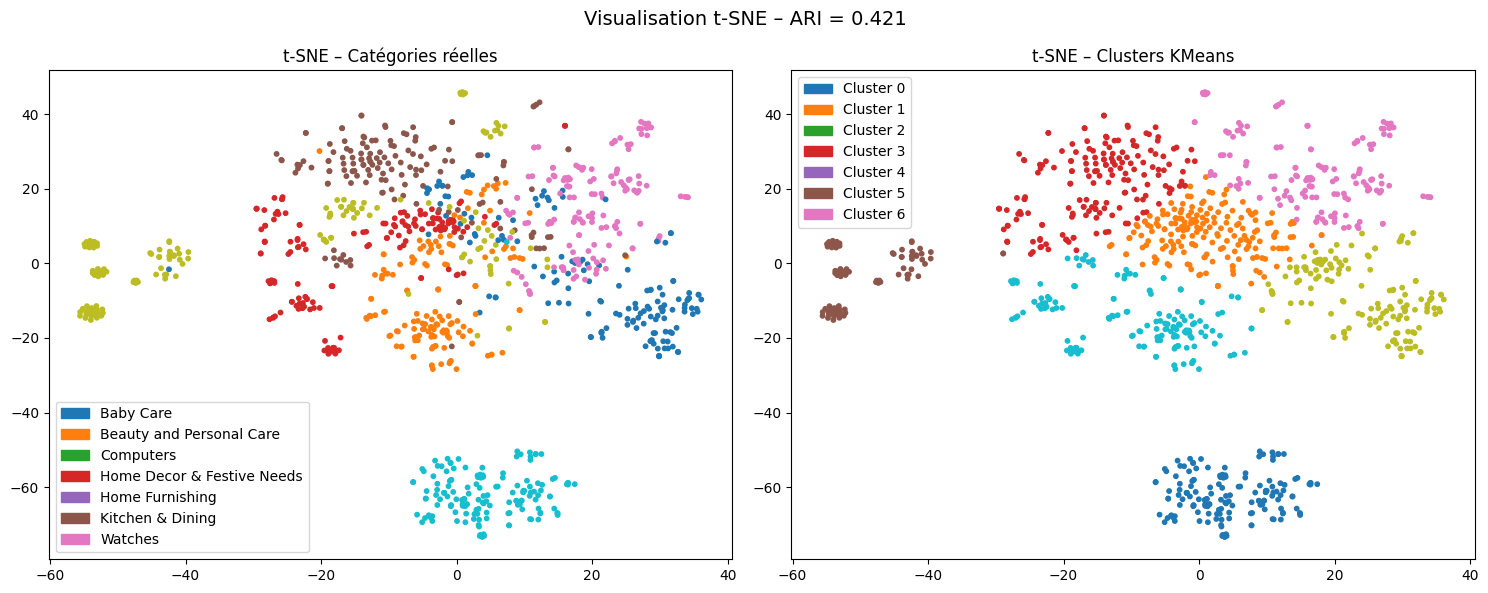

In [28]:
ari_bow_pca_99, X_tsne_bow_pca_99, cluster_labels_bow_pca_99 = ARI_fct(X_bow_pca)
TSNE_visu_fct(X_tsne_bow_pca_99, y_cat_num, cluster_labels_bow_pca_99, ari_bow_pca_99)

<div style="
    font-size: 24px;
    font-weight: bold;
    font-family: Segoe UI;
    color: #374151;
    border-left: 5px solid #3b82f6;
    padding-left: 12px;
    margin: 25px 0 15px 0;
">
    TF-IDF
</div>

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer

# ─── CONSTRUCTION DU TF-IDF ─────────────────────────────────────────────────
vectorizer_tfidf = TfidfVectorizer()
X_tfidf = vectorizer_tfidf.fit_transform(df['final_clean_text'])

print("Shape de la matrice TF-IDF :", X_tfidf.shape)

Shape de la matrice TF-IDF : (1050, 4970)


C:\Users\chouh\anaconda3\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
C:\Users\chouh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


ARI : 0.515   Temps : 12.61s


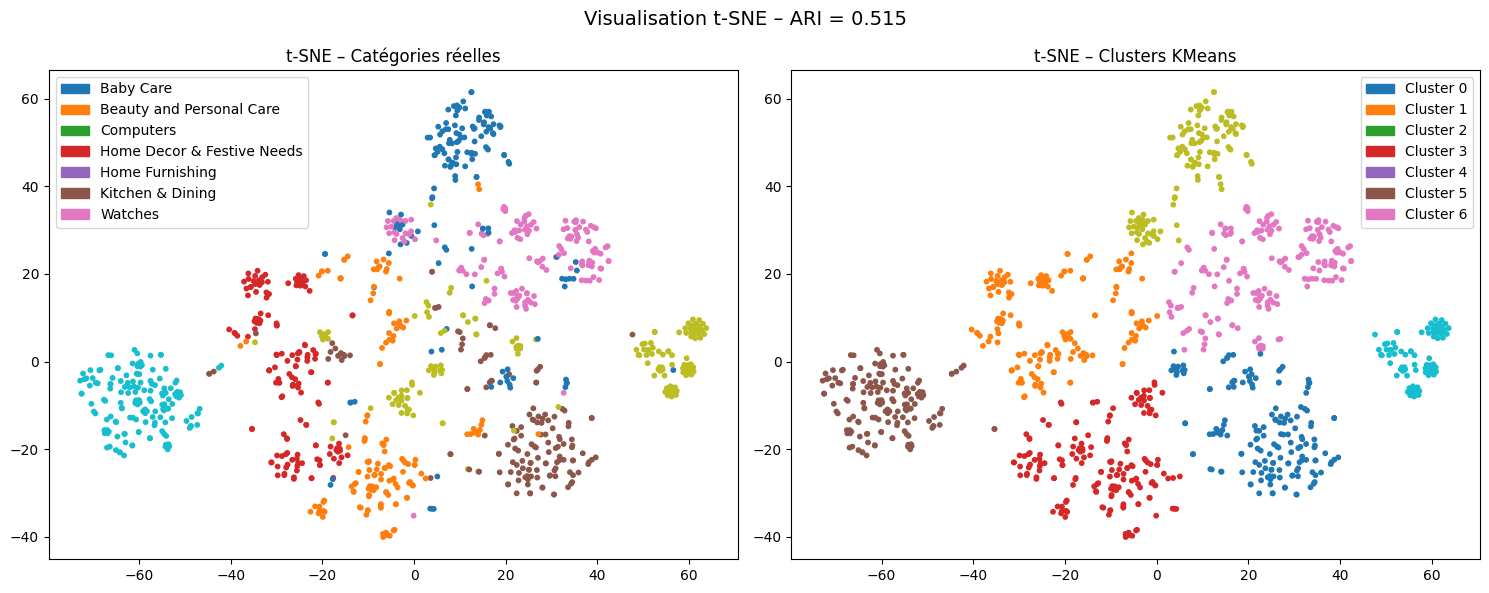

In [31]:
# ─── CALCUL ARI ET AFFICHAGE t-SNE POUR TF-IDF ──────────────────────────────
ari_tfidf, X_tsne_tfidf, cluster_labels_tfidf = ARI_fct(X_tfidf)
TSNE_visu_fct(X_tsne_tfidf, y_cat_num, cluster_labels_tfidf, ari_tfidf)

In [94]:
top_words_table(X_tfidf, cluster_labels_tfidf, vectorizer_tfidf)

,Cluster 0,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5,Cluster 6
0,showpiece (22.549817973494186),laptop (14.132536080249636),combo (20.22628014599267),watch (40.20216052002431),single (12.509039479824917),baby (22.20807677992173),mug (29.16899889182979)
1,sticker (6.678751979661433),usb (13.744514739276692),flipkartcom (17.911799196269335),analog (33.75763772770608),blanket (11.2719303821637),cotton (13.675878066636855),ceramic (17.760196314445977)
2,best (6.44569226890331),battery (9.412218419240897),set (17.635573724445106),men (21.914008941566195),abstract (10.964772842068022),girl (13.41911633780649),rockmantra (7.588026232782784)
3,price (5.3198172107264705),light (8.936223354359768),guarantee (11.189286655835573),woman (16.499951872062432),double (10.263373062921518),towel (13.301501594951826),prithish (7.280830899582189)
4,brass (4.911429082020229),led (8.71145950131591),replacement (10.943809898913555),sonata (12.613659837390564),cover (9.64610843738164),detail (9.936980472096373),perfect (6.900420654591916)


<div style="
    font-size: 24px;
    font-weight: bold;
    font-family: Segoe UI;
    color: #374151;
    border-left: 5px solid #3b82f6;
    padding-left: 12px;
    margin: 25px 0 15px 0;
">
    TF-IDF (version ACP)
</div>

In [34]:
from sklearn.decomposition import PCA

X_tfidf_dense = X_tfidf.toarray()

pca_tfidf = PCA(n_components=0.99, random_state=42)
X_tfidf_pca = pca_tfidf.fit_transform(X_tfidf_dense)

print("Shape après PCA (99% de variance) :", X_tfidf_pca.shape)

Shape après PCA (99% de variance) : (1050, 814)


C:\Users\chouh\anaconda3\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
C:\Users\chouh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


ARI : 0.5677   Temps : 12.77s


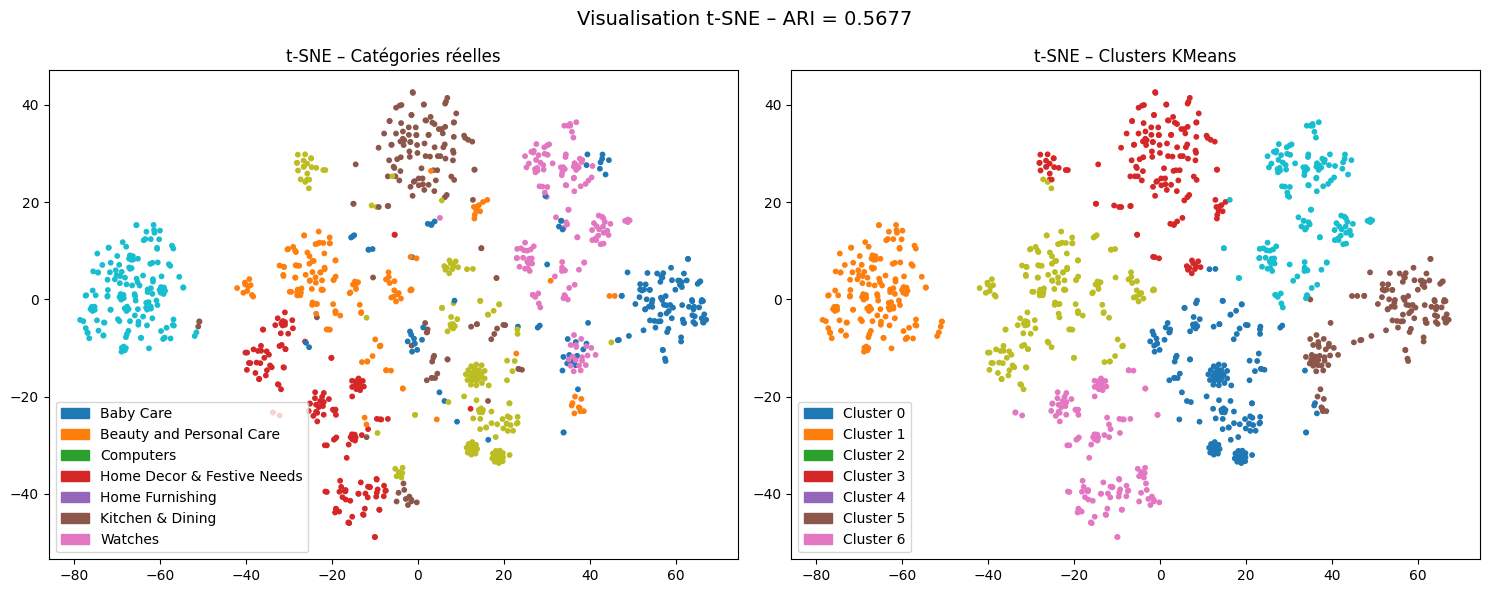

In [35]:
ari_tfidf_pca_99, X_tsne_tfidf_pca_99, cluster_labels_tfidf_pca_99 = ARI_fct(X_tfidf_pca)
TSNE_visu_fct(X_tsne_tfidf_pca_99, y_cat_num, cluster_labels_tfidf_pca_99, ari_tfidf_pca_99)

<div style="
    font-size: 36px;
    font-weight: bold;
    font-family: Segoe UI;
    color: #1f2937;
    border-bottom: 3px solid #3b82f6;
    padding-bottom: 10px;
    margin: 30px 0 20px 0;
    text-align: center
">
    Etape 2 - Etudier la faisabilité de classification en utilisant des méthodes NLP plus avancées
</div>

Après avoir testé des techniques simples comme Bag of Words et TF-IDF, nous avons poursuivi avec des méthodes plus avancées appelées **"embeddings"**.

Les embeddings permettent de **représenter les textes sous forme de vecteurs** qui capturent non seulement les mots présents, mais aussi leur **signification** et leur **contexte**.

### Word2Vec

Word2Vec est une méthode qui apprend à représenter chaque mot par un vecteur de nombres.  
Ces vecteurs sont calculés en fonction du **contexte dans lequel les mots apparaissent** dans les descriptions.

Par exemple, les mots "watch" et "clock" auront des vecteurs très proches, car ils sont souvent utilisés dans les mêmes contextes.

Pour représenter une description entière, nous avons calculé la **moyenne des vecteurs de tous les mots** présents dans le texte.

### Universal Sentence Encoder (USE)

Le modèle **Universal Sentence Encoder** (USE) est une solution pré-entraînée développée par Google.  
Il permet de transformer directement un texte complet en vecteur, sans passer par les mots un par un.

Cette méthode est **rapide, efficace** et déjà **optimisée sur de grandes bases de données**.

### BERT

Nous avons également utilisé le modèle **BERT**, l’un des plus performants aujourd’hui.  
BERT comprend les phrases en **tenant compte du contexte complet**,  
ce qui en fait une solution idéale pour des textes plus complexes.

---

Ces méthodes avancées nous permettent d’aller plus loin que le simple comptage de mots,  
en exploitant la **richesse et la structure des phrases complètes**.


<div style="
    font-size: 24px;
    font-weight: bold;
    font-family: Segoe UI;
    color: #374151;
    border-left: 5px solid #3b82f6;
    padding-left: 12px;
    margin: 25px 0 15px 0;
">
    Word2Vec
</div>

In [37]:
from gensim.models import Word2Vec

# ─── ENTRAÎNEMENT DU MODÈLE WORD2VEC ────────────────────────────────────────
model_w2v = Word2Vec(sentences=df['lemmatized_tokens'], vector_size=200, window=10, min_count=2, workers=4, seed=42)

# ─── VÉRIFICATION ───────────────────────────────────────────────────────────
print("Taille du vocabulaire Word2Vec :", len(model_w2v.wv.index_to_key))

Taille du vocabulaire Word2Vec : 3630


In [38]:
import numpy as np

# ─── FONCTION POUR MOYENNER LES EMBEDDINGS ───────────────────────────────────
def document_vector(doc):
    doc = [word for word in doc if word in model_w2v.wv]
    if len(doc) == 0:
        return np.zeros(model_w2v.vector_size)
    return np.mean(model_w2v.wv[doc], axis=0)

# ─── CONSTRUCTION DE LA MATRICE DOCUMENTS-VECTEURS ──────────────────────────
X_w2v = np.vstack(df['lemmatized_tokens'].apply(document_vector))

print("Shape de la matrice Word2Vec :", X_w2v.shape)

Shape de la matrice Word2Vec : (1050, 200)


C:\Users\chouh\anaconda3\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
C:\Users\chouh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


ARI : 0.2131   Temps : 11.22s


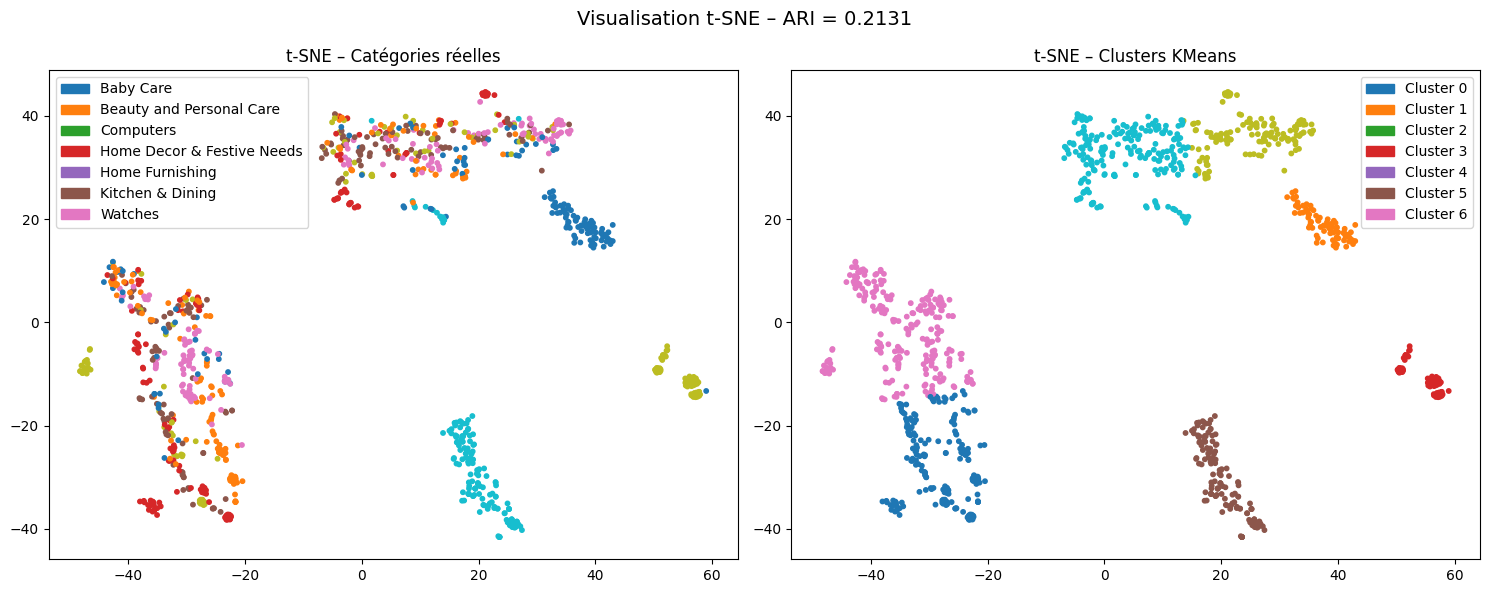

In [39]:
# ─── CALCUL ARI ET AFFICHAGE t-SNE POUR WORD2VEC ────────────────────────────
ari_w2v, X_tsne_w2v, cluster_labels_w2v = ARI_fct(X_w2v)
TSNE_visu_fct(X_tsne_w2v, y_cat_num, cluster_labels_w2v, ari_w2v)

<div style="
    font-size: 24px;
    font-weight: bold;
    font-family: Segoe UI;
    color: #374151;
    border-left: 5px solid #3b82f6;
    padding-left: 12px;
    margin: 25px 0 15px 0;
">
    BERT
</div>

In [41]:
from sentence_transformers import SentenceTransformer

# ─── CHARGEMENT DU MODÈLE BERT ──────────────────────────────────────────────
model_bert = SentenceTransformer('all-MiniLM-L6-v2')

print("BERT chargé avec succès.")

C:\Users\chouh\anaconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Users\chouh\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:144: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\chouh\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular 

BERT chargé avec succès.


In [42]:
# ─── ENCODAGE DES TEXTES AVEC BERT ──────────────────────────────────────────
X_bert = model_bert.encode(df['final_clean_text'].tolist())

print("Shape de la matrice BERT :", X_bert.shape)

Shape de la matrice BERT : (1050, 384)


C:\Users\chouh\anaconda3\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
C:\Users\chouh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


ARI : 0.5558   Temps : 13.18s


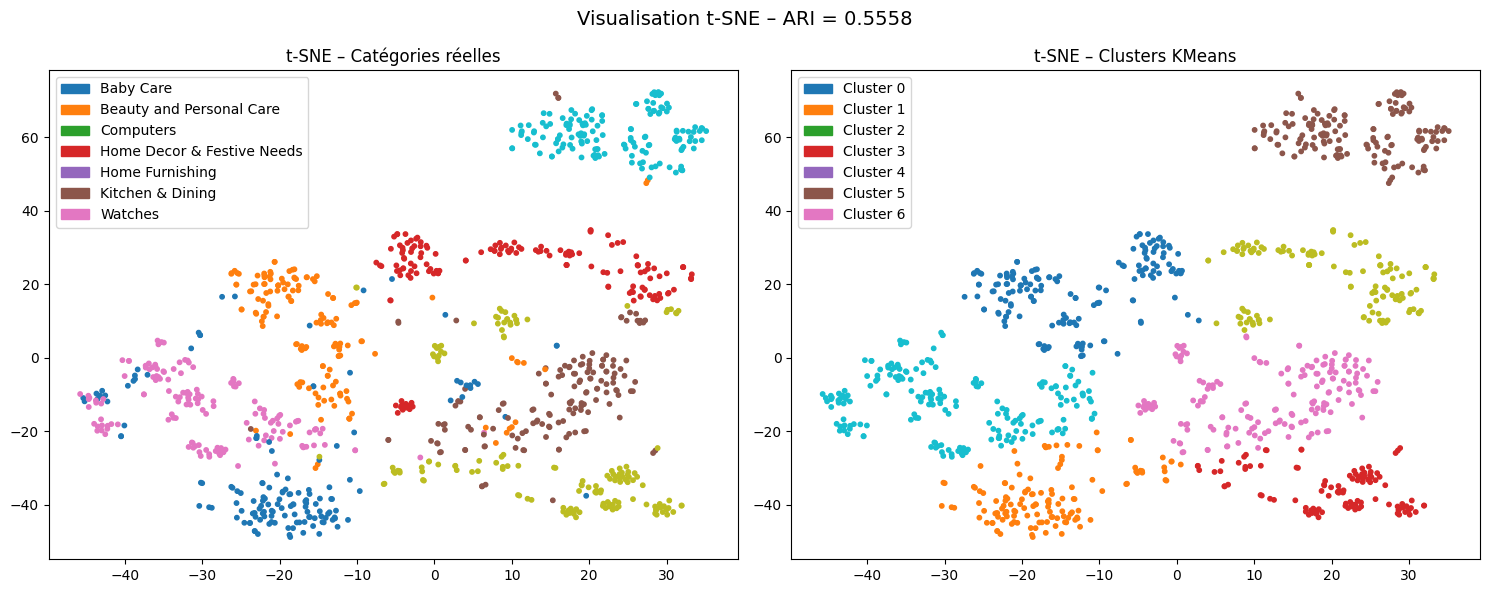

In [43]:
# ─── CALCUL ARI ET AFFICHAGE t-SNE POUR BERT ────────────────────────────────
ari_bert, X_tsne_bert, cluster_labels_bert = ARI_fct(X_bert)
TSNE_visu_fct(X_tsne_bert, y_cat_num, cluster_labels_bert, ari_bert)

<div style="
    font-size: 24px;
    font-weight: bold;
    font-family: Segoe UI;
    color: #374151;
    border-left: 5px solid #3b82f6;
    padding-left: 12px;
    margin: 25px 0 15px 0;
">
    USE
</div>

In [48]:
from sentence_transformers import SentenceTransformer

# ─── CHARGEMENT DU MODÈLE ALTERNATIF ────────────────────────────────────────
model_use_alt = SentenceTransformer('all-mpnet-base-v2')

print("Modèle USE chargé avec succès.")

Modèle USE alternatif chargé avec succès.


In [50]:
# ─── ENCODAGE DES TEXTES ────────────────────────────────────────────────────
X_use_alt = model_use_alt.encode(df['final_clean_text'].tolist())

print("Shape des embeddings USE :", X_use_alt.shape)

Shape des embeddings USE alternatifs : (1050, 768)


C:\Users\chouh\anaconda3\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
C:\Users\chouh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


ARI : 0.7426   Temps : 13.13s


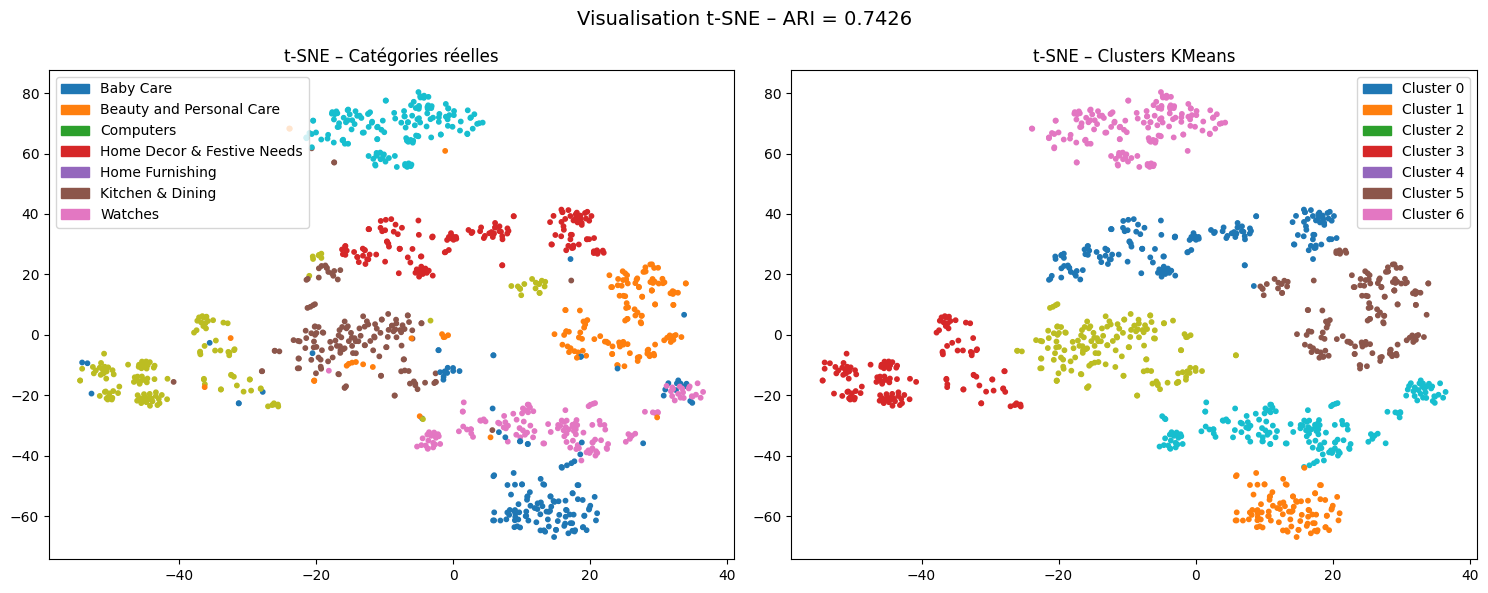

In [52]:
# ─── CALCUL ARI ET AFFICHAGE t-SNE POUR USE ALTERNATIF ──────────────────────
ari_use_alt, X_tsne_use_alt, cluster_labels_use_alt = ARI_fct(X_use_alt)
TSNE_visu_fct(X_tsne_use_alt, y_cat_num, cluster_labels_use_alt, ari_use_alt)

<div style="
    font-size: 32px;
    font-weight: bold;
    font-family: Segoe UI;
    color: #1f2937;
    border-bottom: 3px solid #3b82f6;
    padding-bottom: 10px;
    margin: 30px 0 20px 0;
    text-align: center
">
    Synthèse des résultats
</div>

In [108]:
import pandas as pd

# ─── SYNTHÈSE DES SCORES ARI ─────────────────────────────────────────────────
results = {
    "Méthode": [
        "Bag of Words", 
        "Bag of Words + PCA", 
        "TF-IDF", 
        "TF-IDF + PCA", 
        "Word2Vec",
        "USE", 
        "BERT"
    ],
    "ARI": [
        ari_bow, 
        ari_bow_pca_99, 
        ari_tfidf, 
        ari_tfidf_pca_99, 
        ari_w2v, 
        ari_use_alt, 
        ari_bert
    ]
}

df_results = pd.DataFrame(results)
df_results.sort_values(by="ARI", ascending=False, inplace=True)

print("Comparaison des ARI obtenus :")
display(df_results)

Comparaison des ARI obtenus :


,Méthode,ARI
5,USE,0.7426
3,TF-IDF + PCA,0.5677
6,BERT,0.5558
2,TF-IDF,0.5150
0,Bag of Words,0.4608
1,Bag of Words + PCA,0.4210
4,Word2Vec,0.2131


## Conclusion et recommandations

Nous avons testé plusieurs techniques pour représenter les descriptions des produits afin d’envisager une classification automatique.

### Analyse des résultats

Le tableau ci-dessus compare les performances des différentes méthodes, mesurées par l'indicateur ARI.  
Plus l'ARI est élevé, mieux la méthode arrive à retrouver les vraies catégories.

Nous constatons que :
- **USE** arrive en tête avec un ARI de **0.74**, ce qui montre une **très bonne capacité à regrouper les produits**.
- **TF-IDF + PCA** et **BERT** obtiennent également des scores intéressants, autour de **0.55 - 0.57**.
- Les méthodes **Bag of Words** et **Word2Vec**, plus simples, montrent des performances plus faibles, autour de **0.21 à 0.46**,  
  ce qui les rend **moins adaptés** à notre cas.

### Recommandation

Compte tenu des résultats obtenus :
- **Le modèle USE** est le **plus performant** et **le plus adapté** à notre objectif.
- Il permet de capturer le **sens des descriptions**, ce qui est particulièrement pertinent pour des **fiches produits courtes et variées** comme celles de Flipkart.

Nous recommandons donc de **poursuivre les développements** en nous appuyant sur cette méthode,  
qui offre le **meilleur compromis entre performance et généralisation** pour ce type de données e-commerce.

In [ ]:
# ─── SAUVEGARDE DU DATAFRAME ────────────────────────────────────────────────
#df.to_csv("flipkart_preprocessed.csv", index=False)
#print("Fichier 'flipkart_preprocessed.csv' sauvegardé avec succès.")